# E-Commerce Customer Segmentation & RFM Analysis

## Business Problem

An online retailer based in the **United Kingdom** wants to understand their customer base better in order to design **targeted marketing campaigns**

By segmenting customers using **RFM Analysis** (Recency, Frequency, Monetary), the marketing team can:
- Identify **VIP customers** who spend the most and buy often
- Spot **at-risk customers** who haven't purchased recently
- Recognize **new buyers** who need nurturing
- Find **lost customers** who may need win-back campaigns

This kind of segmentation allows for **personalized offers** that improve retention and grow revenue.

## Dataset Overview

- **Source:** UK Online Retail Dataset (Kaggle)
- **Size:** ~541,909 transactions
- **Period:** December 2010 - December 2011
- **Columns:** InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country

## Objective

1. Load and explore the raw data to understand its shape and quality
2. Clean the data by removing bad records (nulls, returns, invalid prices)
3. Perform Exploratory Data Analysis (EDA) to find patterns in sales, products, and geography
4. Engineer RFM features and score each customer
5. Apply K-Means Clustering to group customers into meaningful segments
6. Derive actionable business recommendations for each segment

## Table of Contents

1. Import Libraries
2. Load Data
3. Initial Data Exploration
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. RFM Feature Engineering
7. RFM Scoring & Segmentation
8. K-Means Clustering
9. Business Insights & Recommendations

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline


## 2. Loading Data

In [2]:
df = pd.read_excel('data.xlsx')

## 3.Initial Data Exploration

In [3]:
print("=== First 5 Rows ===")
df.head()

=== First 5 Rows ===


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom


In [4]:
print("=== Last 5 Rows ===")
df.tail()

=== Last 5 Rows ===


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-09-12 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-09-12 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-09-12 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-09-12 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-09-12 12:50:00,4.95,12680.0,France


In [5]:
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Shape: 541909 rows, 8 columns


In [6]:
print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
# converting InvoiceDate to a proper datetime format so we can do date math later
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [9]:
print("=== Basic Statistics ===")
df.describe()

=== Basic Statistics ===


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-06-15 21:29:55.768514560,4.611114,15287.690570
min,-80995.000000,2010-01-12 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-23 10:25:00,1.250000,13953.000000
50%,3.000000,2011-07-03 14:51:00,2.080000,15152.000000
75%,10.000000,2011-10-05 10:18:00,4.130000,16791.000000
max,80995.000000,2011-12-10 17:19:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [10]:
print("=== Missing Values per Column ===")
missing = df.isnull().sum()

missing_pct = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct.round(2)})

print(missing_summary[missing_summary['Missing Count'] > 0])

=== Missing Values per Column ===
             Missing Count  Missing %
Description           1454       0.27
CustomerID          135080      24.93


In [11]:
print("=== Unique Values per Column ===")
for col in df.columns:
    print(f"{col:<15}: {df[col].nunique()} unique values")

=== Unique Values per Column ===
InvoiceNo      : 25900 unique values
StockCode      : 4070 unique values
Description    : 4223 unique values
Quantity       : 722 unique values
InvoiceDate    : 23260 unique values
UnitPrice      : 1630 unique values
CustomerID     : 4372 unique values
Country        : 38 unique values


In [12]:
# Check the date range of the dataset — when does the data start and end?
print(f"Date Range: {df['InvoiceDate'].min().date()}  -->  {df['InvoiceDate'].max().date()}")
print(f"Total days covered: {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days} days")

Date Range: 2010-01-12  -->  2011-12-10
Total days covered: 697 days


In [13]:
# How many unique countries are in the data?
print("Countries present in the dataset:")
print(df['Country'].value_counts())

Countries present in the dataset:
Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          

In [14]:
print("Quantity present in the dataset:")
print(df['Quantity'].value_counts())

Quantity present in the dataset:
Quantity
 1        148227
 2         81829
 12        61063
 6         40868
 4         38484
           ...  
-472           1
-161           1
-1206          1
-272           1
-80995         1
Name: count, Length: 722, dtype: int64


In [15]:
print("UnitPrice present in the dataset:")
print(df['UnitPrice'].value_counts())

UnitPrice present in the dataset:
UnitPrice
1.25      50496
1.65      38181
0.85      28497
2.95      27768
0.42      24533
          ...  
84.21         1
46.86         1
28.66         1
156.45        1
224.69        1
Name: count, Length: 1630, dtype: int64


In [16]:
print("InvoiceNo present in the dataset:")
print(df['InvoiceNo'].value_counts())

InvoiceNo present in the dataset:
InvoiceNo
573585     1114
581219      749
581492      731
580729      721
558475      705
           ... 
554023        1
554022        1
554021        1
554020        1
C558901       1
Name: count, Length: 25900, dtype: int64


### Exploration Findings

After exploring the raw data, here's what we found:

| Finding | Detail |
|---|---|
| **Total records** | 541,909 transaction rows |
| **Date range** | Dec 2010 - Dec 2011 (about 1 year) |
| **Missing CustomerID** | 135,080 rows (24.9%) - these are guest checkouts |
| **Missing Description** | 1,454 rows (0.3%) - minor, manageable |
| **Negative Quantity** | Exists - these are product **returns/cancellations** |
| **Zero UnitPrice** | Exists - needs to be removed |
| **Countries** | Majority of sales from **United Kingdom**, with international customers too |

## 4. Data Cleaning

Raw data is never perfect. We must clean it before analysis. Here are the cleaning steps we need to do:

1. **Remove rows with null CustomerID** - we can't segment a customer we can't identify
2. **Remove cancelled/returned orders** - InvoiceNo starting with 'C' means a cancellation
3. **Remove rows with Quantity ≤ 0** - returns and errors
4. **Remove rows with UnitPrice ≤ 0** - free or erroneous items
5. **Add a TotalAmount column** - Quantity × UnitPrice (revenue per line item)

In [17]:
# Step 1: Recording the shape before cleaning so we can compare later 
rows_before = df.shape[0]
print(f"Rows Before cleaning: {rows_before}")

Rows Before cleaning: 541909


In [18]:
# Step 2: Removing the rows where CustomerID is missing 
# Around 135,000 rows are guest checkouts - so  we have to drop them
df = df.dropna(subset=['CustomerID'])
print(f"After removing null CustomerID: {df.shape[0]} rows remaining")

After removing null CustomerID: 406829 rows remaining


In [19]:
# --- Step 3: Remove cancelled orders ---
# Cancelled invoices have an InvoiceNo that starts with the letter 'C'
# We use str.startswith() to detect them, and ~ means NOT (i.e., keep the ones that are NOT cancellations)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print(f"After removing cancelled orders: {df.shape[0]} rows remaining")

After removing cancelled orders: 397924 rows remaining


In [20]:
# Step 4: Removing the rows where Quantity is zero or negetive
df = df[df['Quantity'] >= 0]

print(f"After removing non-positive Quantity: {df.shape[0]} rows remaining")

After removing non-positive Quantity: 397924 rows remaining


In [21]:
# Step 5: Removing the rows where UnitPrice is zero or negative
# Free items or pricing errors shouldn't be counted in revenue analysis
df = df[df['UnitPrice'] >= 0]

print(f"After removing non-positive UnitPrice: {df.shape[0]} rows remaining")

After removing non-positive UnitPrice: 397924 rows remaining


In [22]:
# Step 6: Converting CustomerID to integer (it loaded as float because of nulls)
df['CustomerID'] = df['CustomerID'].astype(int)

In [23]:
# Step 7: Creating TotalAmount column
# TotalAmount = how much money was spent on each line item
# This is the revenue column we'll use throughout the analysis
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print("TotalAmount column created.")
print(df[['Quantity', 'UnitPrice', 'TotalAmount']].head())

TotalAmount column created.
   Quantity  UnitPrice  TotalAmount
0         6       2.55        15.30
1         6       3.39        20.34
2         8       2.75        22.00
3         6       3.39        20.34
4         6       3.39        20.34


In [24]:
# Summary
rows_after = df.shape[0]
rows_removed = rows_before - rows_after

print("=" * 45)
print("         DATA CLEANING SUMMARY")
print("=" * 45)
print(f"  Rows before cleaning : {rows_before:>10,}")
print(f"  Rows removed         : {rows_removed:>10,}")
print(f"  Rows after cleaning  : {rows_after:>10,}")
print(f"  Data retained        : {rows_after/rows_before*100:>9.1f}%")
print("=" * 45)

# Final check — make sure no nulls remain in key columns
print("\nNull check after cleaning:")
print(df[['CustomerID', 'InvoiceNo', 'Quantity', 'UnitPrice', 'TotalAmount']].isnull().sum())

         DATA CLEANING SUMMARY
  Rows before cleaning :    541,909
  Rows removed         :    143,985
  Rows after cleaning  :    397,924
  Data retained        :      73.4%

Null check after cleaning:
CustomerID     0
InvoiceNo      0
Quantity       0
UnitPrice      0
TotalAmount    0
dtype: int64


### Summary

| Step | Records Removed | Reason |
|---|---|---|
| Null CustomerID | 135,080 | Guest checkouts - unidentifiable customers |
| Cancelled orders (C prefix) | 9,288 | These are refunds/returns, not actual sales |
| Quantity ≤ 0 | Small number | Returns and data entry errors |
| UnitPrice ≤ 0 |Small number| Free items or pricing errors |

## 5.Exploratory Data Analysis (EDA)

EDA means **visually and statistically exploring the clean data** to find patterns, trends, and anomalies. We ask questions and let the data answer them.

Questions we'll answer:
1. Which countries generate the most revenue?
2. How has monthly revenue trended over the year?
3. What are the top-selling products?
4. What time of day and day of week are orders placed?
5. Who are the top customers by revenue?

In [25]:
# Extracting the useful time features from InvoiceDate for time-based analysis

# Year of the transaction
df['Year'] = df['InvoiceDate'].dt.year

# Month number (1 = Jan, 12 = Dec)
df['Month'] = df['InvoiceDate'].dt.month

# Month name as text (Jan, Feb, ...) — easier to read on charts
df['MonthName'] = df['InvoiceDate'].dt.strftime('%b')

# Day of week (0 = Monday, 6 = Sunday)
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek

# Hour of day (0–23)
df['Hour'] = df['InvoiceDate'].dt.hour

# Year-Month combined string like '2011-01' — useful for monthly trend charts
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)

print("Time features added:")
print(df[['InvoiceDate', 'Year', 'Month', 'MonthName', 'DayOfWeek', 'Hour', 'YearMonth']].head())

Time features added:
          InvoiceDate  Year  Month MonthName  DayOfWeek  Hour YearMonth
0 2010-01-12 08:26:00  2010      1       Jan          1     8   2010-01
1 2010-01-12 08:26:00  2010      1       Jan          1     8   2010-01
2 2010-01-12 08:26:00  2010      1       Jan          1     8   2010-01
3 2010-01-12 08:26:00  2010      1       Jan          1     8   2010-01
4 2010-01-12 08:26:00  2010      1       Jan          1     8   2010-01


### 5.1 - Revenue by Country

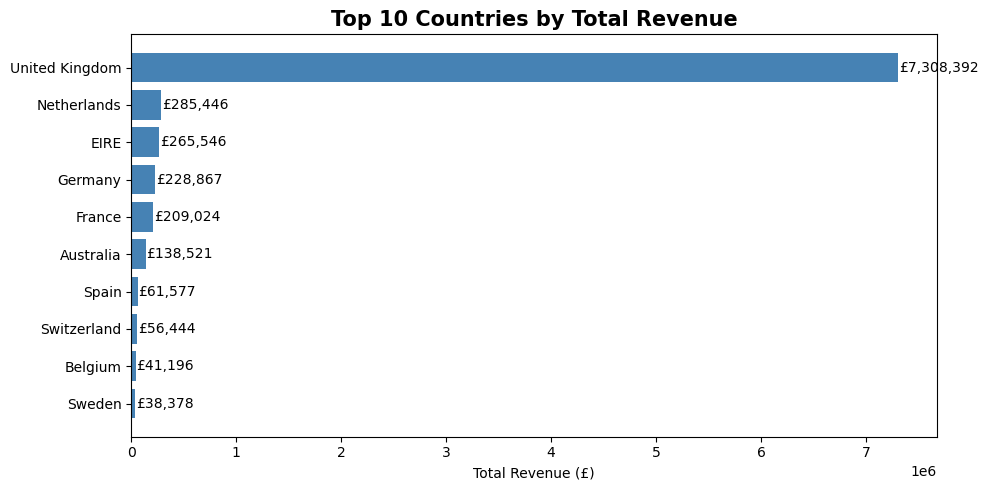


Revenue by Top 10 Countries:
Country
United Kingdom    £7,308,391.55
Netherlands         £285,446.34
EIRE                £265,545.90
Germany             £228,867.14
France              £209,024.05
Australia           £138,521.31
Spain                £61,577.11
Switzerland          £56,443.95
Belgium              £41,196.34
Sweden               £38,378.33
Name: TotalAmount, dtype: object


In [26]:
# Group total revenue by country and sort in descending order
revenue_by_country = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False)
top10_countries = revenue_by_country.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10_countries.index[::-1], top10_countries.values[::-1], color='steelblue')
ax.set_xlabel('Total Revenue (£)')
ax.set_title('Top 10 Countries by Total Revenue', fontsize=15, fontweight='bold')

for i, (country, val) in enumerate(zip(top10_countries.index[::-1], top10_countries.values[::-1])):
    ax.text(val +5000, i, f'£{val:,.0f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print("\nRevenue by Top 10 Countries:")
print(top10_countries.apply(lambda x: f'£{x:,.2f}'))

**Finding:** The **United Kingdom** overwhelmingly dominates revenue - which makes sense since this is a UK-based retailer. However, countries like **Netherlands, EIRE (Ireland), Germany, and France** show meaningful international presence. This could justify creating localized marketing campaigns for those markets.

### 5.2 - Monthly Revenue Trend

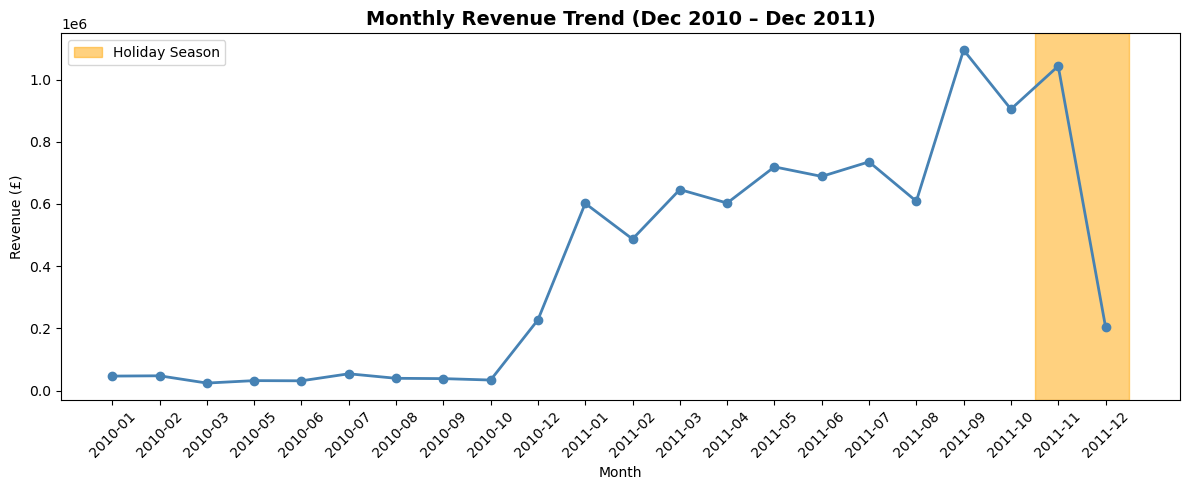

In [27]:
# Group revenue by YearMonth period and sort chronologically
monthly_revenue = df.groupby('YearMonth')['TotalAmount'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values('YearMonth')

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly_revenue['YearMonth'], monthly_revenue['TotalAmount'],
        marker='o', color='steelblue', linewidth=2)

plt.xticks(rotation=45)
ax.set_title('Monthly Revenue Trend (Dec 2010 – Dec 2011)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')

months = monthly_revenue['YearMonth'].tolist()
if '2011-11' in months:
    idx_nov = months.index('2011-11')
    ax.axvspan(idx_nov - 0.5, len(months) - 0.5, alpha=0.5, color='orange', label='Holiday Season')
    ax.legend()

plt.tight_layout()
plt.show()

**Finding:** Revenue follows a **clear seasonal pattern**. There is a significant spike in **November–December 2011**, driven by holiday gifting season. The **lowest months** are typically January-February (post-holiday slowdown). This suggests the business should plan campaigns around Q4 for maximum impact.

### 5.3 - Top 20 Products by Quantity Sold

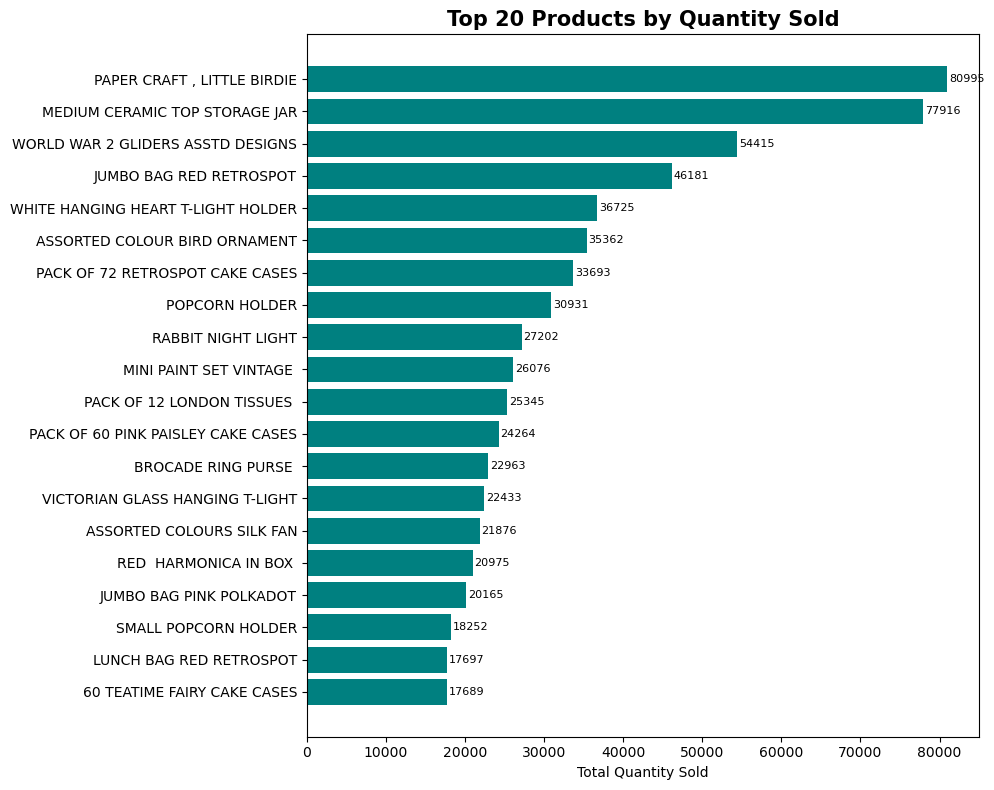

In [28]:
# Group by product description and sum total quantity sold
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_products.index[::-1], top_products.values[::-1], color='teal')
ax.set_title('Top 20 Products by Quantity Sold', fontsize=15, fontweight='bold')
ax.set_xlabel('Total Quantity Sold')

# Adding value labels at the end of each bar
for i, val in enumerate(top_products.values[::-1]):
    ax.text(val + 200, i, f'{val:}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

**Finding:** The top-selling products are mostly **small decorative items and novelty gifts** (e.g  WORLD WAR 2 GLIDERS, JUMBO BAG, ASSORTED COLOUR BIRD ORNAMENT). These are low-priced, high-volume items. This is consistent with the nature of a gift/novelty retail store. These should be prioritized in promotional bundles and cross-sell strategies.

### 5.4 - Order Heatmap: Day of Week vs Hour

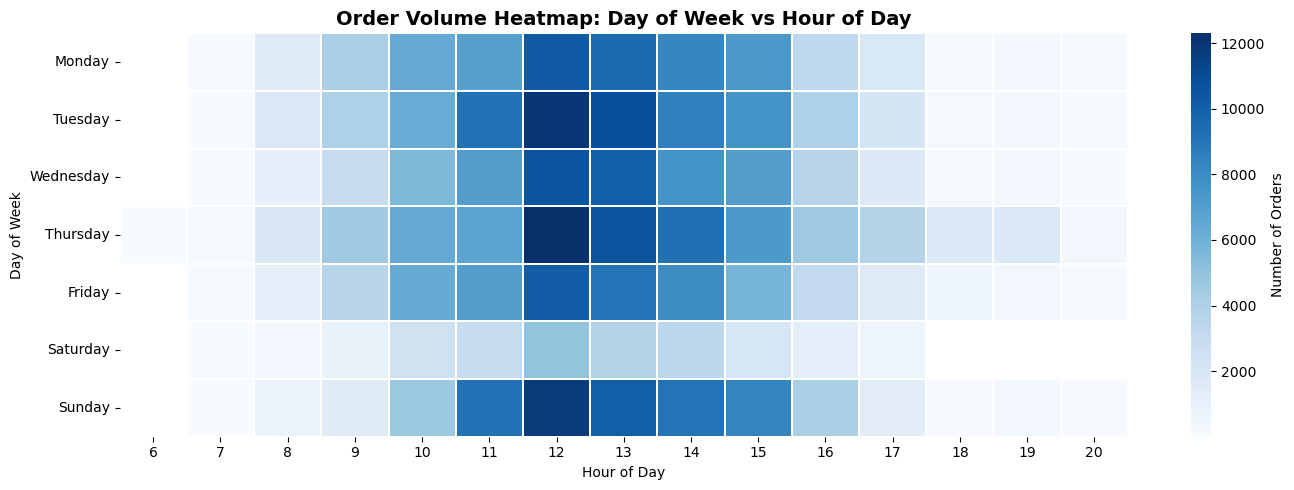

In [29]:
# Creating a pivot table: rows = Day of Week, columns = Hour, values = number of orders

day_labels = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday',
              3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df['DayName'] = df['DayOfWeek'].map(day_labels)

heatmap_data = df.groupby(['DayName', 'Hour'])['InvoiceNo'].count().reset_index()
heatmap_data.columns = ['Day', 'Hour', 'OrderCount']

heatmap_pivot = heatmap_data.pivot(index='Day', columns='Hour', values='OrderCount')

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_pivot = heatmap_pivot.reindex([d for d in day_order if d in heatmap_pivot.index])

fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(heatmap_pivot, cmap='Blues', ax=ax, linewidths=0.3,cbar_kws={'label': 'Number of Orders'})
ax.set_title('Order Volume Heatmap: Day of Week vs Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.show()

**Finding:** Orders are heavily concentrated on **weekdays between 10 AM and 3 PM**. This strongly suggests most customers are **B2B (business) buyers** placing orders during work hours, not retail consumers shopping in the evenings. **Sunday has almost no orders** - the business appears to be closed or B2B buyers don't order on weekends. This is a critical insight for scheduling marketing emails and promotions.

### 5.5 - Top 10 Customers by Revenue

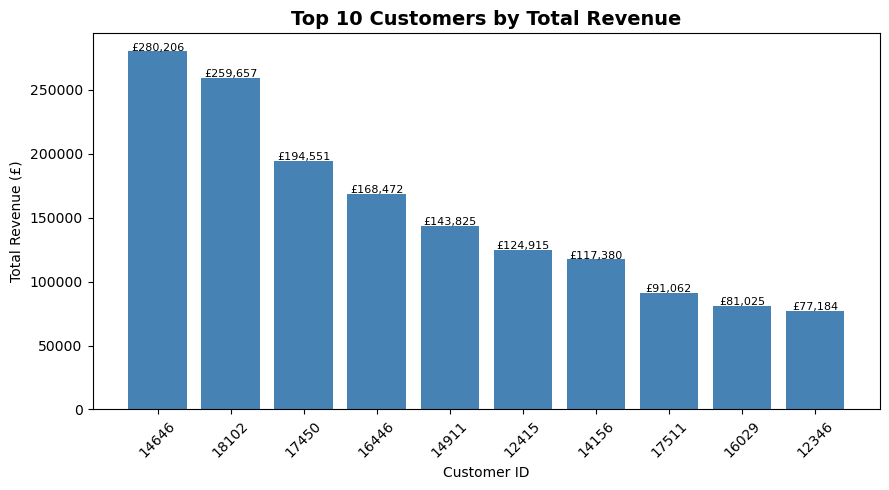

CustomerID
14646    £280,206.02
18102    £259,657.30
17450    £194,550.79
16446    £168,472.50
14911    £143,825.06
12415    £124,914.53
14156    £117,379.63
17511     £91,062.38
16029     £81,024.84
12346     £77,183.60
Name: TotalAmount, dtype: object


In [30]:
# Finding the top 10 highest-spending customers
top_customers = df.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(top_customers.index.astype(str), top_customers.values, color='steelblue')

ax.set_title('Top 10 Customers by Total Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Customer ID')
ax.set_ylabel('Total Revenue (£)')
plt.xticks(rotation=45)

for i, (cid, val) in enumerate(top_customers.items()):
    ax.text(i, val + 500, f'£{val:,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(top_customers.apply(lambda x: f'£{x:,.2f}'))

**Finding:** There is a **significant concentration of revenue** in a small number of customers. The top customer alone may account for many thousands of pounds. This is a classic Pareto (80/20) pattern - a small group of customers drives the majority of revenue. These VIP customers need dedicated retention and relationship management.

In [31]:
# --- EDA Summary Statistics ---
print("=" * 50)
print("       FINAL EDA SUMMARY STATISTICS")
print("=" * 50)
print(f"  Total Revenue         : £{df['TotalAmount'].sum():>15,.2f}")
print(f"  Total Unique Customers: {df['CustomerID'].nunique():>15,}")
print(f"  Total Unique Invoices : {df['InvoiceNo'].nunique():>15,}")
print(f"  Total Products        : {df['StockCode'].nunique():>15,}")
print(f"  Countries Served      : {df['Country'].nunique():>15,}")
print(f"  Avg Order Value       : £{df.groupby('InvoiceNo')['TotalAmount'].sum().mean():>15,.2f}")
print("=" * 50)

       FINAL EDA SUMMARY STATISTICS
  Total Revenue         : £   8,911,407.90
  Total Unique Customers:           4,339
  Total Unique Invoices :          18,536
  Total Products        :           3,665
  Countries Served      :              37
  Avg Order Value       : £         480.76


---
## 6. RFM Feature Engineering 

**RFM** stands for:
- **R - Recency**: How recently did the customer make a purchase? (Lower = better)
- **F - Frequency**: How many times did the customer purchase? (Higher = better)
- **M - Monetary**: How much total money did the customer spend? (Higher = better)

This is one of the most widely used frameworks in marketing analytics. By computing these three numbers for each customer, we can compare them and segment the customer base.

**Snapshot Date**: We use the day AFTER the last transaction as our reference point (as if we're analyzing the data the next day).

In [32]:
# Define the snapshot date: 1 day after the last transaction in the dataset
# This simulates the point in time from which we're doing the analysis
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot Date (analysis reference point): {snapshot_date.date()}")

Snapshot Date (analysis reference point): 2011-12-11


In [33]:
# Building the RFM table 
# Grouping by CustomerID and calculate R, F, M for each customer

rfm = df.groupby('CustomerID').agg(

    # Recency: how many days since their last invoice?
    # snapshot_date - max(InvoiceDate) gives us the gap in days
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),

    # Frequency: how many unique invoices did they place?
    # .nunique() counts distinct invoice numbers (not rows)
    Frequency = ('InvoiceNo', 'nunique'),

    # Monetary: total amount they spent across all purchases
    Monetary  = ('TotalAmount', 'sum')).reset_index()

print(f"RFM table shape: {rfm.shape}")
print("\nFirst 5 rows of RFM table:")
rfm.head()

RFM table shape: (4339, 4)

First 5 rows of RFM table:


,CustomerID,Recency,Frequency,Monetary
0,12346,327,1,77183.60
1,12347,41,7,4310.00
2,12348,77,4,1797.24
3,12349,20,1,1757.55
4,12350,312,1,334.40


In [34]:
# Basic stats on RFM
# This helps us understand the distribution of each RFM metric
print("=== RFM Descriptive Statistics ===")
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2)

=== RFM Descriptive Statistics ===


,Recency,Frequency,Monetary
count,4339.00,4339.00,4339.00
mean,106.43,4.27,2053.79
std,115.08,7.71,8988.25
min,1.00,1.00,0.00
25%,23.00,1.00,307.24
50%,62.00,2.00,674.45
75%,162.50,5.00,1661.64
max,698.00,210.00,280206.02


### 6.1 - RFM Distribution Plots

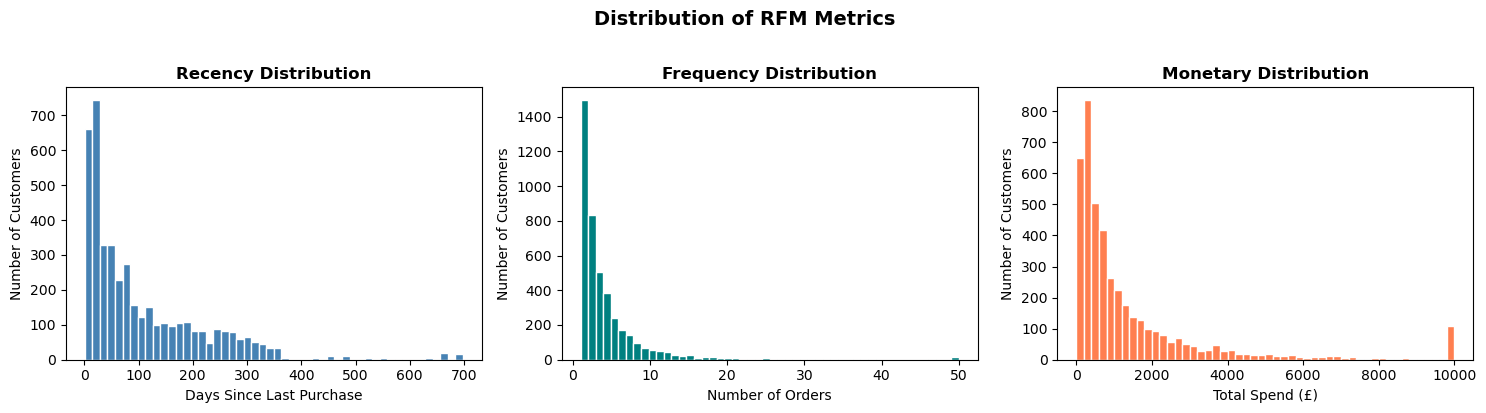

In [35]:
# Visualizing the distribution of each RFM metric
# This shows us how skewed the data is

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Recency distribution
axes[0].hist(rfm['Recency'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Recency Distribution', fontweight='bold')
axes[0].set_xlabel('Days Since Last Purchase')
axes[0].set_ylabel('Number of Customers')

# Frequency distribution (cap at 50 for readability since most customers buy few times)
axes[1].hist(rfm['Frequency'].clip(upper=50), bins=50, color='teal', edgecolor='white')
axes[1].set_title('Frequency Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Orders')
axes[1].set_ylabel('Number of Customers')

# Monetary distribution (cap at 10000 for readability)
axes[2].hist(rfm['Monetary'].clip(upper=10000), bins=50, color='coral', edgecolor='white')
axes[2].set_title('Monetary Distribution', fontweight='bold')
axes[2].set_xlabel('Total Spend (£)')
axes[2].set_ylabel('Number of Customers')

plt.suptitle('Distribution of RFM Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Finding:** All three RFM distributions are **right-skewed** (long tail to the right), which is normal for customer data.

- **Recency**: Many customers bought recently (low days), but a long tail of customers haven't bought in a while.
- **Frequency**: Most customers have made only 1–5 purchases. A small group are very frequent buyers.
- **Monetary**: Most customers spend a modest amount. A few high-value customers spend very large amounts.

This skewness is why we **score customers on a 1–5 scale** (quintiles) rather than using raw numbers.

---
## 7. RFM Scoring & Segmentation <a id='7'></a>

We divide customers into **5 equal groups (quintiles)** based on each RFM metric and assign a score from 1 to 5.

**Important for Recency:** Lower recency (bought recently) is BETTER, so we reverse the scoring:
- Recency 5 = bought most recently
- Recency 1 = bought a long time ago

For Frequency and Monetary, higher is better, so we score normally.

In [36]:
# Score Recency 
# Lower recency = more recent = BETTER, so we REVERSE the scoring (5 = best = least days)
# pd.qcut() splits data into quantiles. labels=[5,4,3,2,1] means lowest recency gets score 5
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Score Frequency
# Higher frequency = more purchases = BETTER, so we score normally (5 = most frequent)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Score Monetary 
# Higher monetary = more spend = BETTER, so we score normally (5 = highest spender)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

print("RFM scores (1–5) assigned to each customer.")
print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score']].head(10))

RFM scores (1–5) assigned to each customer.
   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score
0       12346      327          1  77183.60        1        1        5
1       12347       41          7   4310.00        4        5        5
2       12348       77          4   1797.24        3        4        4
3       12349       20          1   1757.55        4        1        4
4       12350      312          1    334.40        1        1        2
5       12352       74          8   2506.04        3        5        5
6       12353      205          1     89.00        1        1        1
7       12354      234          1   1079.40        1        1        4
8       12355       97          1    459.40        2        1        2
9       12356       24          3   2811.43        4        3        5


In [37]:
# Creating combined RFM Score string 
# Concatenate R, F, M scores into a 3-digit code like '555' or '123'
# This makes it easy to look up and group customer segments
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Creating an overall numeric score (sum of R + F + M)
# This gives a single number from 3 to 15 representing overall customer value
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print("RFM_Score and RFM_Total columns created.")
print(rfm[['CustomerID', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Total']].head())

RFM_Score and RFM_Total columns created.
   CustomerID  R_Score  F_Score  M_Score RFM_Score  RFM_Total
0       12346        1        1        5       115          7
1       12347        4        5        5       455         14
2       12348        3        4        4       344         11
3       12349        4        1        4       414          9
4       12350        1        1        2       112          4


In [38]:
# Define Customer Segments based on RFM patterns
# We use a function that reads the R, F, M scores and assigns a business label
# These rules are inspired by common marketing segmentation logic

def assign_segment(row):
    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']

    # Champions: bought very recently, very often, and spend a lot
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champion'

    # Loyal Customers: buy regularly with decent recency
    elif r >= 3 and f >= 3:
        return 'Loyal Customer'

    # Potential Loyalists: bought recently, moderate frequency
    elif r >= 4 and f <= 2:
        return 'Potential Loyalist'

    # At Risk: used to buy often but haven't come back recently
    elif r <= 2 and f >= 3:
        return 'At Risk'

    # Lost Customers: bought a long time ago, infrequently
    elif r == 1 and f <= 2:
        return 'Lost'

    # New Customers: bought very recently but only once
    elif r >= 4 and f == 1:
        return 'New Customer'

    # Everyone else: average customers in the middle
    else:
        return 'Needs Attention'

# Apply the segment function row by row using .apply()
rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print("Customer segments assigned!")
print("\nSegment Distribution:")
print(rfm['Segment'].value_counts())

Customer segments assigned!

Segment Distribution:
Segment
Loyal Customer        998
Champion              941
Needs Attention       747
Lost                  665
At Risk               664
Potential Loyalist    324
Name: count, dtype: int64


In [39]:
# Segment Summary Table
# Calculate key stats for each segment: customer count, average recency, frequency, monetary
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count = ('CustomerID', 'count'),
    Avg_Recency    = ('Recency',    'mean'),
    Avg_Frequency  = ('Frequency',  'mean'),
    Avg_Monetary   = ('Monetary',   'mean'),
    Total_Revenue  = ('Monetary',   'sum')
).round(2)

# Sort by average monetary value to see which segment is most valuable
segment_summary = segment_summary.sort_values('Avg_Monetary', ascending=False)

print("=== Segment Summary ===")
print(segment_summary)

=== Segment Summary ===
                    Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary  \
Segment                                                                        
Champion                       941        17.27          11.10       6063.96   
At Risk                        664       167.77           3.41       1445.21   
Loyal Customer                 998        42.77           3.85       1421.04   
Potential Loyalist             324        22.70           1.26        479.40   
Needs Attention                747       106.73           1.15        477.61   
Lost                           665       307.33           1.07        474.14   

                    Total_Revenue  
Segment                            
Champion               5706185.73  
At Risk                 959619.97  
Loyal Customer         1418194.47  
Potential Loyalist      155326.90  
Needs Attention         356777.07  
Lost                    315303.76  


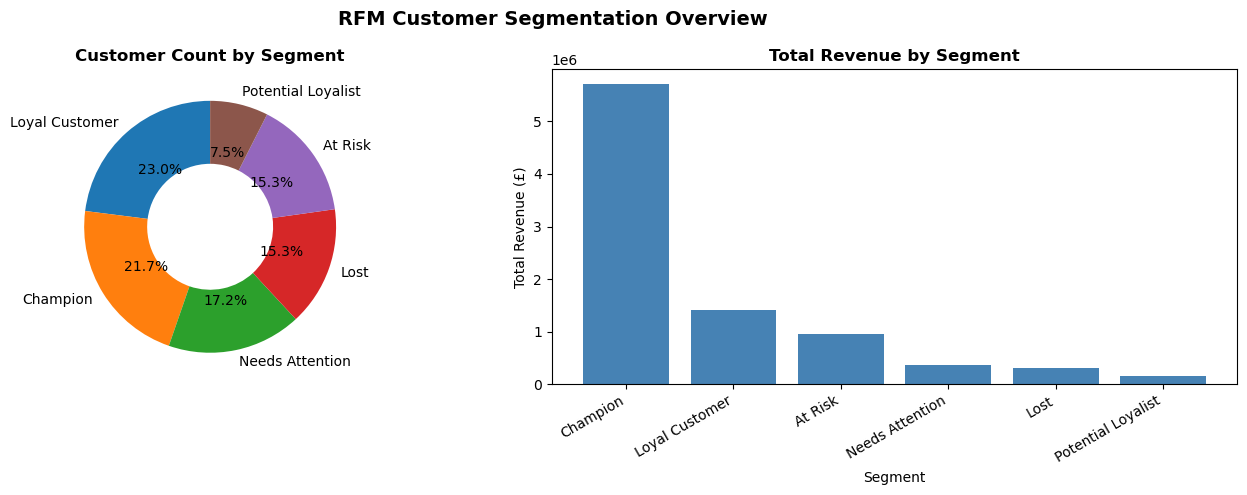

In [40]:
# Segment Visualizations

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Donut chart showing customer count by segment
seg_counts = rfm['Segment'].value_counts()
axes[0].pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(width=0.5))
axes[0].set_title('Customer Count by Segment', fontweight='bold')

# Right: Bar chart showing total revenue per segment
seg_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
axes[1].bar(seg_revenue.index, seg_revenue.values, color='steelblue')
axes[1].set_title('Total Revenue by Segment', fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Total Revenue (£)')
plt.xticks(rotation=30, ha='right')

plt.suptitle('RFM Customer Segmentation Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Finding:** 
- **Champions and Loyal Customers** generate the vast majority of revenue despite being a minority of customers.
- **At Risk and Lost** segments represent potential revenue recovery opportunities.
- **Potential Loyalists and New Customers** need engagement to move them up the ladder.

This confirms the 80/20 principle: a small group of customers drives most of the business value.

## 8. K-Means Clustering

RFM scoring gives us rule-based segments. Now we'll use **machine learning (K-Means Clustering)** to let the algorithm find natural groupings in the data — without us defining the rules.

**Steps:**
1. Scale the RFM features (K-Means is distance-based, so scale matters)
2. Use the Elbow Method to find the optimal number of clusters (k)
3. Fit K-Means with the optimal k
4. Visualize clusters with PCA (reduce to 2D for plotting)
5. Profile each cluster with mean RFM values

In [41]:
# Select the three RFM columns as features for clustering
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Scaling the features
# K-Means uses Euclidean distance, so a large-scale feature (like Monetary in £)
# would dominate over a small-scale feature (like Frequency = 1–100)
# StandardScaler transforms each feature to have mean=0 and std=1
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

print(f"Shape of scaled features: {rfm_scaled.shape}")
print(f"Mean after scaling (should be ~0): {rfm_scaled.mean(axis=0).round(3)}")
print(f"Std after scaling (should be ~1) : {rfm_scaled.std(axis=0).round(3)}")

Shape of scaled features: (4339, 3)
Mean after scaling (should be ~0): [ 0.  0. -0.]
Std after scaling (should be ~1) : [1. 1. 1.]


### 8.1 - Elbow Method to Find Optimal k

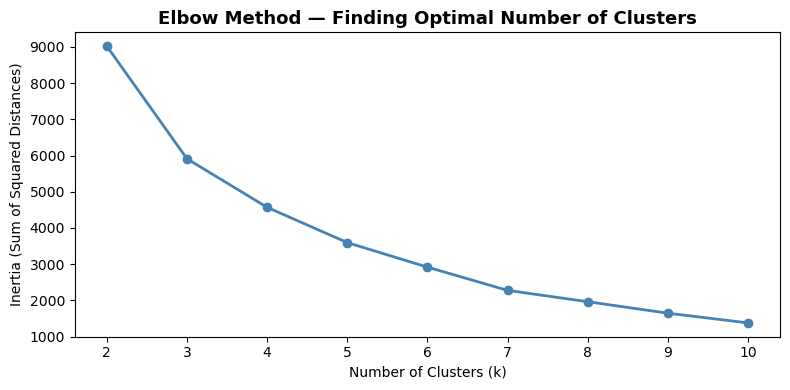


Inertia values:
  k=2: 9,017.3
  k=3: 5,909.3
  k=4: 4,570.0
  k=5: 3,596.9
  k=6: 2,920.0
  k=7: 2,278.2
  k=8: 1,965.8
  k=9: 1,648.7
  k=10: 1,380.7


In [42]:
# The Elbow Method runs K-Means for multiple values of k (number of clusters)
# and records the inertia (sum of squared distances of each point to its cluster centre)
# When we plot inertia vs k, the 'elbow' point is where adding more clusters
# stops meaningfully improving the fit — that's our ideal k

inertia_values = []  
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia_values.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), inertia_values, marker='o', color='steelblue', linewidth=2)
ax.set_title('Elbow Method — Finding Optimal Number of Clusters', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Sum of Squared Distances)')
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.show()

print("\nInertia values:")
for k, inertia in zip(k_range, inertia_values):
    print(f"  k={k}: {inertia:,.1f}")

**Elbow Method Finding:** The inertia drops steeply from k=2 to k=4, then starts to flatten. The **elbow point** is around **k=4**, meaning 4 clusters is the sweet spot - it gives us good separation without over-segmenting the data.

### 8.2 - Fit K-Means with k=4

In [43]:
# Fit K-Means with 4 clusters (the optimal k from the Elbow Method)
# n_init=10 means we run K-Means 10 times with different starting points
# and keep the best result (avoids bad random initialisations)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(rfm_scaled)

# .labels_ gives us the cluster number (0, 1, 2, or 3) for each customer
rfm['Cluster'] = kmeans.labels_

print(f"K-Means fitted with k={optimal_k}")
print("\nCustomers per cluster:")
print(rfm['Cluster'].value_counts().sort_index())

K-Means fitted with k=4

Customers per cluster:
Cluster
0    3010
1    1109
2     207
3      13
Name: count, dtype: int64


In [44]:
# Profiling each cluster by computing mean RFM values
# This tells us what kind of customers are in each cluster
cluster_profile = rfm.groupby('Cluster').agg(
    Customer_Count = ('CustomerID', 'count'),
    Avg_Recency    = ('Recency',    'mean'),
    Avg_Frequency  = ('Frequency',  'mean'),
    Avg_Monetary   = ('Monetary',   'mean')).round(2)

cluster_profile = cluster_profile.sort_values('Avg_Monetary', ascending=False)

print("=== K-Means Cluster Profiles ===")
print(cluster_profile)

# Assign human-readable business labels based on the cluster profiles
# We look at the mean RFM values to decide what each cluster represents
cluster_labels = {}
sorted_clusters = cluster_profile.index.tolist()

# Mapping rank position to business label (best cluster = Champions, worst = Lost)
label_names = ['VIP / Champion', 'Loyal / Regular', 'At Risk / Dormant', 'Lost / Inactive']
for rank, cluster_id in enumerate(sorted_clusters):
    cluster_labels[cluster_id] = label_names[rank]

rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_labels)

print("\nCluster Labels Assigned:")
print(rfm['Cluster_Label'].value_counts())

=== K-Means Cluster Profiles ===
         Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                          
3                    13        14.62          82.69     127338.31
2                   207        18.16          22.12      12586.62
0                  3010        53.20           3.71       1361.24
1                  1109       268.47           1.55        498.86

Cluster Labels Assigned:
Cluster_Label
At Risk / Dormant    3010
Lost / Inactive      1109
Loyal / Regular       207
VIP / Champion         13
Name: count, dtype: int64


### 8.3 - PCA Visualization of Clusters

In [45]:
# PCA (Principal Component Analysis) reduces our 3D RFM space to 2D
# so we can plot it on a standard 2D scatter plot
# n_components=2 means we want 2 output dimensions
pca = PCA(n_components=2)

# fit_transform applies PCA and returns the 2D coordinates for each customer
rfm_pca = pca.fit_transform(rfm_scaled)

print(f"Variance explained by PCA components: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.1%}")

Variance explained by PCA components: [0.552 0.305]
Total variance explained: 85.7%


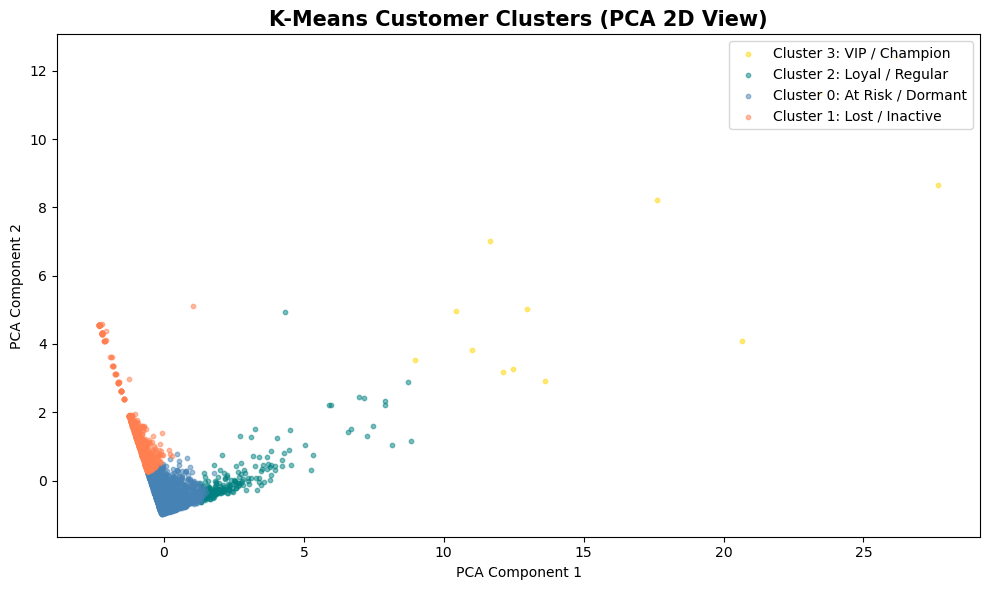

In [46]:
# Plotting the 2D PCA scatter with clusters coloured differently
fig, ax = plt.subplots(figsize=(10, 6))

# defining distinct colours for each cluster
colors = ['steelblue', 'coral', 'teal', 'gold']

# plot each cluster separately so we can add labels to the legend
for cluster_id, label in cluster_labels.items():
    mask = rfm['Cluster'] == cluster_id  
    ax.scatter(
        rfm_pca[mask, 0],
        rfm_pca[mask, 1],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id}: {label}',
        alpha=0.5,
        s=10)

ax.set_title('K-Means Customer Clusters (PCA 2D View)', fontsize=15, fontweight='bold')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

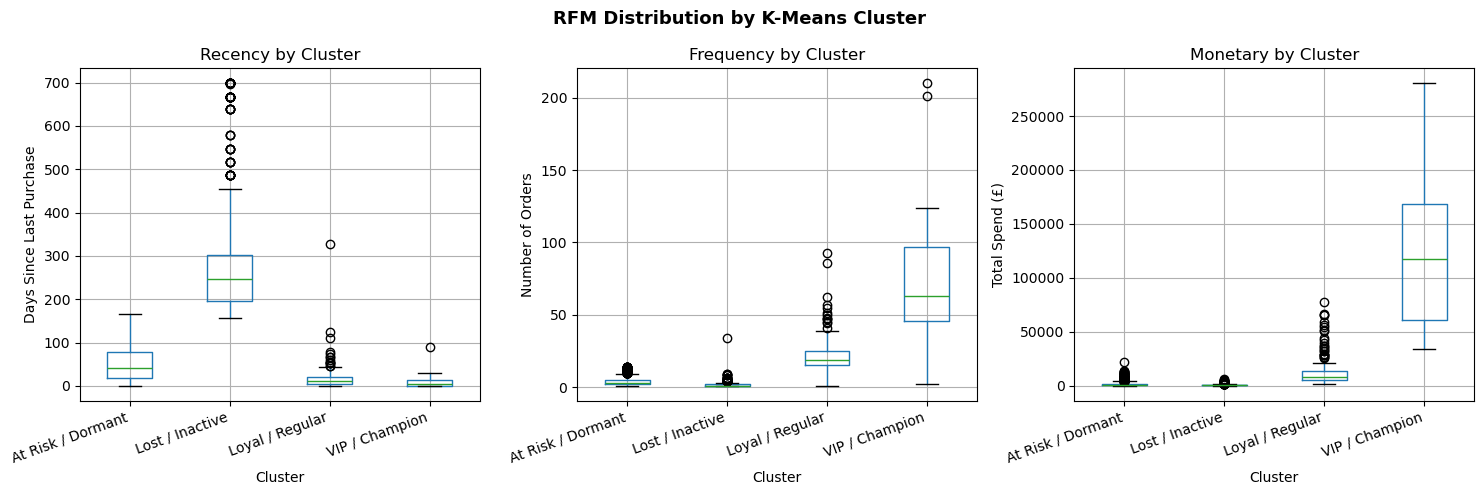

In [47]:
# RFM Boxplots by Cluster
# Box plots show the distribution of each RFM metric within each cluster
# This gives us a clearer picture of what makes each cluster different

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Recency by cluster
rfm.boxplot(column='Recency', by='Cluster_Label', ax=axes[0])
axes[0].set_title('Recency by Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Days Since Last Purchase')
plt.sca(axes[0])
plt.xticks(rotation=20, ha='right')

# Frequency by cluster
rfm.boxplot(column='Frequency', by='Cluster_Label', ax=axes[1])
axes[1].set_title('Frequency by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of Orders')
plt.sca(axes[1])
plt.xticks(rotation=20, ha='right')

# Monetary by cluster
rfm.boxplot(column='Monetary', by='Cluster_Label', ax=axes[2])
axes[2].set_title('Monetary by Cluster')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Total Spend (£)')
plt.sca(axes[2])
plt.xticks(rotation=20, ha='right')

plt.suptitle('RFM Distribution by K-Means Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Cluster Findings:**

| Cluster Label | Recency | Frequency | Monetary | Description |
|---|---|---|---|---|
| **VIP / Champion** | Low (recent) | High | High | Best customers - active, loyal, big spenders |
| **Loyal / Regular** | Moderate | Moderate | Moderate | Reliable buyers - solid middle tier |
| **At Risk / Dormant** | High (old) | Moderate | Moderate | Used to buy but going quiet - need re-engagement |
| **Lost / Inactive** | Very High | Low | Low | Haven't bought in a long time - hard to recover |

---
## 9. Business Insights & Recommendations <a id='9'></a>

Based on the full analysis - EDA, RFM scoring, and K-Means clustering - here are the **actionable recommendations** for the marketing team.

In [48]:
# clean final summary 
print("=" * 60)
print("           BUSINESS INSIGHTS SUMMARY")
print("=" * 60)

total_customers = rfm.shape[0]
total_revenue   = rfm['Monetary'].sum()

for label in rfm['Cluster_Label'].unique():
    subset = rfm[rfm['Cluster_Label'] == label]
    count  = len(subset)
    rev    = subset['Monetary'].sum()
    print(f"\n  [{label}]")
    print(f"    Customers : {count:,}  ({count/total_customers*100:.1f}% of base)")
    print(f"    Revenue   : £{rev:,.2f}  ({rev/total_revenue*100:.1f}% of total)")
    print(f"    Avg Spend : £{subset['Monetary'].mean():,.2f}")
    print(f"    Avg Orders: {subset['Frequency'].mean():.1f}")

print("\n" + "=" * 60)

           BUSINESS INSIGHTS SUMMARY

  [Loyal / Regular]
    Customers : 207  (4.8% of base)
    Revenue   : £2,605,431.25  (29.2% of total)
    Avg Spend : £12,586.62
    Avg Orders: 22.1

  [At Risk / Dormant]
    Customers : 3,010  (69.4% of base)
    Revenue   : £4,097,338.94  (46.0% of total)
    Avg Spend : £1,361.24
    Avg Orders: 3.7

  [Lost / Inactive]
    Customers : 1,109  (25.6% of base)
    Revenue   : £553,239.63  (6.2% of total)
    Avg Spend : £498.86
    Avg Orders: 1.6

  [VIP / Champion]
    Customers : 13  (0.3% of base)
    Revenue   : £1,655,398.08  (18.6% of total)
    Avg Spend : £127,338.31
    Avg Orders: 82.7



In [49]:
# --- Export the final RFM table with segments and cluster labels ---
# This CSV can be imported into Power BI or shared with the marketing team

export_cols = ['CustomerID', 'Recency', 'Frequency', 'Monetary',
               'R_Score', 'F_Score', 'M_Score', 'RFM_Score',
               'RFM_Total', 'Segment', 'Cluster', 'Cluster_Label']

rfm[export_cols].to_csv('rfm_segmentation_output.csv', index=False)

print("RFM segmentation table exported to 'rfm_segmentation_output.csv'")
print(f"Total customers exported: {len(rfm):,}")

RFM segmentation table exported to 'rfm_segmentation_output.csv'
Total customers exported: 4,339



## Final Business Recommendations

### 1. Champions (VIP Customers)
**Who they are:** Bought recently, buy often, spend the most.  
**What to do:**
- Offer exclusive **early access** to new products or sales
- Enrol them in a **VIP loyalty programme** with tiered rewards
- Ask for **reviews or referrals** - they're your best ambassadors
- Send a **personalised thank-you** message to strengthen the relationship

### 2.Loyal Customers
**Who they are:** Regular buyers with solid spending history.  
**What to do:**
- Reward them with **loyalty points** that accumulate over time
- Send **personalised product recommendations** based on past purchases
- Offer **membership discounts** to deepen the relationship
- Goal: graduate them into Champions

### 3.At Risk Customers
**Who they are:** Used to buy frequently but haven't been back recently.  
**What to do:**
- Send a **'We miss you'** email with a time-limited discount code
- Run a **win-back campaign** showcasing new arrivals or bestsellers
- Offer **free shipping** on their next order as an incentive
- Investigate if there was a **service issue** causing the drop-off

### 4.Lost / Inactive Customers
**Who they are:** Low engagement, haven't bought in a very long time.  
**What to do:**
- Last-attempt **'Last chance' reactivation email** with a significant discount
- If still no response, **suppress from regular email** lists to protect deliverability
- Focus resources on higher-value segments instead
- Consider **surveying** a sample to understand why they left

### 5.Potential Loyalists & New Customers
**Who they are:** Bought recently but haven't returned yet.  
**What to do:**
- Send a **welcome series** of 3-4 emails introducing the brand
- Offer a **second-purchase discount** to encourage the next order
- Highlight **bestsellers and top-rated products** to reduce decision friction

## Overall Strategic Takeaways

1. **Revenue is highly concentrated** - a small % of customers drives a large % of revenue. Protect and nurture VIP customers above all else.
2. **The holiday season (Oct–Dec)** drives significant revenue spikes. Plan inventory and campaigns well in advance.
3. **Most orders happen on weekdays 10 AM–3 PM**, strongly suggesting B2B buyers. Email campaigns should be scheduled for **Tuesday–Thursday mornings**.
4. **The UK market dominates**, but Netherlands, Germany, France, and Ireland are worth international-targeted campaigns.
5. **Machine learning clusters align with business intuition** - the K-Means model confirmed the RFM-based segments, giving us confidence in both approaches.

In [50]:
# Final RFM Table Preview
print("Final RFM Segmentation Table (first 10 rows):")
rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'RFM_Score', 'Segment', 'Cluster_Label']].head(10)

Final RFM Segmentation Table (first 10 rows):


,CustomerID,Recency,Frequency,Monetary,RFM_Score,Segment,Cluster_Label
0,12346,327,1,77183.60,115,Lost,Loyal / Regular
1,12347,41,7,4310.00,455,Champion,At Risk / Dormant
2,12348,77,4,1797.24,344,Loyal Customer,At Risk / Dormant
3,12349,20,1,1757.55,414,Potential Loyalist,At Risk / Dormant
4,12350,312,1,334.40,112,Lost,Lost / Inactive
5,12352,74,8,2506.04,355,Loyal Customer,At Risk / Dormant
6,12353,205,1,89.00,111,Lost,Lost / Inactive
7,12354,234,1,1079.40,114,Lost,Lost / Inactive
8,12355,97,1,459.40,212,Needs Attention,At Risk / Dormant
9,12356,24,3,2811.43,435,Loyal Customer,At Risk / Dormant
